# Audit Notebook: Simulated Field Telemetry vs `clean_telemetry.py`

In the *Cleaning TestDrive* project the cleaning was done **manually**: plot every
attribute, decide NOISE vs NATURAL by eye, then hand-tune a filter per column.
Here the pipeline is automated (`clean_telemetry.py`), so this notebook has a different job:
**audit the script's output** and decide if it is good enough.

We have one big advantage over the manual notebook: the data comes from `simulate_field.py`,
so we know *exactly* which faults were injected (**ground truth**). The simulator drives a
physically consistent car model (burn-and-coast driving, cumulative integrals, voltage sag)
and corrupts only the *outgoing messages* with five fault types:

| # | Injected fault | Rate | Signature in the data |
|---|---|---|---|
| 1 | Packet loss | 12% | gap in `ts` (row never arrives) |
| 2 | Network latency | 10% | 2-5 s stall, shows up as a `ts` gap too |
| 3 | Sensor spike | 4% | `velocity` = 999.9 **and** `gForceZ` = 5.0 (same row) |
| 4 | Velocity zero-dropout | ~3% | `velocity` = 0.0 while the car is moving |
| 5 | QoS1 duplicate | 3% | identical row delivered twice |

So the audit question for every attribute is:
**did the script remove exactly the injected faults and nothing else?**
Cleaning a natural fluctuation would be just as much of a failure as missing a glitch.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

raw = pd.read_csv('data/falcon_telemetry.csv')
cl  = pd.read_csv('data/falcon_telemetry_cleaned.csv')
with open('data/falcon_telemetry_cleaned_report.json') as f:
    report = json.load(f)

# shared clock: seconds since first raw sample
t0 = raw['ts'].min()
t_raw = (raw['ts'] - t0) / 1000.0
t_cl  = (cl['ts']  - t0) / 1000.0

print(f"raw rows: {len(raw)}   cleaned rows: {len(cl)}")
print(f"duplicates dropped: {report['duplicate_rows_dropped']}")
print(f"median sample interval: {report['median_interval_ms']:.0f} ms")
print(f"packet-loss gaps reported: {len(report['gaps'])}")

raw rows: 432   cleaned rows: 416
duplicates dropped: 16
median sample interval: 354 ms
packet-loss gaps reported: 35


### Chart conventions

Raw (uncleaned) data is always drawn in **orange**, cleaned data in **blue**, on the
same elapsed-time axis so rows line up between the two. Each figure keeps a single
y-axis; when two attributes must be compared (e.g. voltage vs current) they get
stacked panels that share the time axis, never a second y-scale.

In [2]:
RAW_C, CLEAN_C = '#eb6834', '#2a78d6'      # orange = raw, blue = cleaned
INK, MUTED, GRID, AXIS = '#0b0b0b', '#52514e', '#e1e0d9', '#c3c2b7'
plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white',
                     'font.size': 10, 'axes.titlelocation': 'left',
                     'axes.titleweight': 'bold', 'axes.titlecolor': INK})

def style_ax(ax):
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
    for side in ('left', 'bottom'):
        ax.spines[side].set_color(AXIS)
    ax.grid(axis='y', color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=MUTED, labelsize=9)

def compare(col, ylabel, title):
    """Raw on top (orange), cleaned below (blue), shared time axis."""
    fig, (a1, a2) = plt.subplots(2, 1, figsize=(12, 5.5), sharex=True)
    a1.plot(t_raw, raw[col], color=RAW_C, lw=1.4)
    a1.set_title(f'{title} — raw')
    a2.plot(t_cl, cl[col], color=CLEAN_C, lw=1.4)
    a2.set_title(f'{title} — cleaned')
    a2.set_xlabel('elapsed time (s)', color=MUTED)
    for a in (a1, a2):
        a.set_ylabel(ylabel, color=MUTED)
        style_ax(a)
    plt.tight_layout()
    plt.show()

---
## 1. Velocity — injected NOISE on top of a natural driving cycle

The raw panel is dominated by the 999.9 km/h spike faults (fault #3) — they blow the
y-scale up so far that the real signal is a flat band at the bottom. The cleaned panel
reveals what was underneath: the **burn-and-coast sawtooth** (accelerate to ~27 km/h,
coast down to ~18 km/h, repeat). That sawtooth is the *natural* signal and must survive
cleaning untouched.

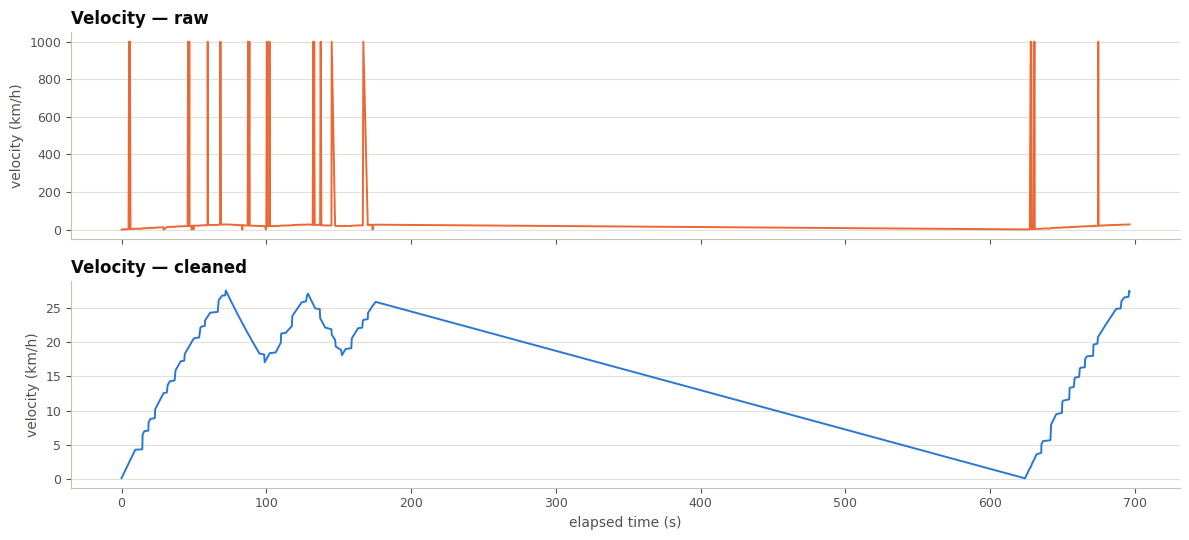

In [3]:
compare('velocity', 'velocity (km/h)', 'Velocity')

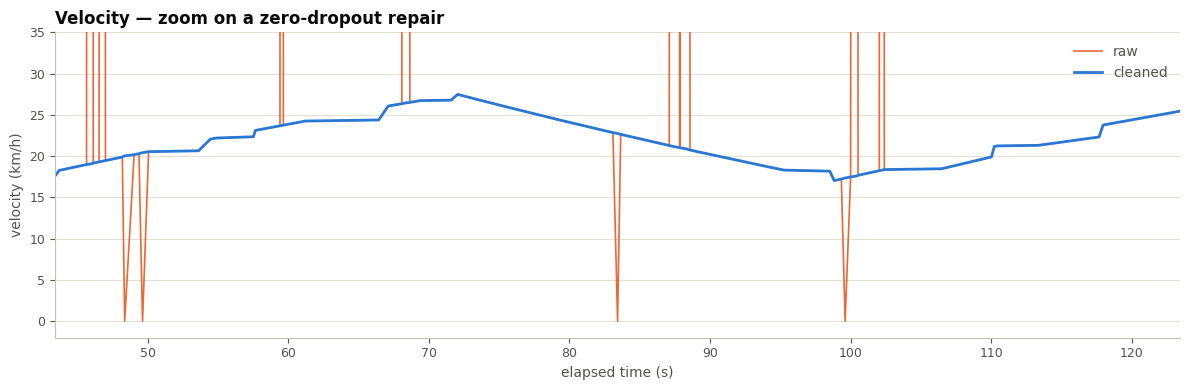

script caught: 20 spikes (bounds), 6 zero-dropouts, interpolated 26 points


In [4]:
# zoom: overlay raw and cleaned at natural scale to inspect the repairs
zeros = raw.index[(raw['velocity'] == 0)].tolist()
zoom_c = t_raw.iloc[zeros[len(zeros)//2]] if zeros else t_raw.iloc[len(raw)//2]
lo, hi = zoom_c - 40, zoom_c + 40

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t_raw, raw['velocity'], color=RAW_C, lw=1.2, label='raw')
ax.plot(t_cl, cl['velocity'], color=CLEAN_C, lw=2.0, label='cleaned')
ax.set_xlim(lo, hi); ax.set_ylim(-2, 35)
ax.set_title('Velocity — zoom on a zero-dropout repair')
ax.set_xlabel('elapsed time (s)', color=MUTED); ax.set_ylabel('velocity (km/h)', color=MUTED)
ax.legend(frameon=False, labelcolor=MUTED)
style_ax(ax)
plt.tight_layout(); plt.show()

v = report['columns']['velocity']
print(f"script caught: {v.get('out_of_bounds',0)} spikes (bounds), "
      f"{v.get('zero_glitches',0)} zero-dropouts, interpolated {v.get('interpolated',0)} points")

**Verdict: correctly cleaned.**
- The 999.9 spikes are removed by the physical bounds rule (velocity can't exceed 120 km/h) —
  not by statistics, so there is zero risk of a false positive here.
- The zero-dropouts (fault #4) are caught by the dedicated zero-glitch rule: a 0 *between two
  moving samples* is physically impossible, while a long run of zeros (a real stop at the start
  line) would be left alone.
- In the zoom you can see the repair is a straight **linear interpolation** bridging the flagged
  point — the surrounding sawtooth shape is untouched. This matches the manual notebook's rule:
  detect-then-interpolate, never blanket-smooth.

---
## 2. gForceZ — the statistical (MAD) detector at work

The spike fault corrupts `gForceZ` to 5.0 in the *same rows* as the velocity 999.9.
Unlike velocity, 5.0 g is inside the plausible physical bounds (±8 g), so the bounds rule
can't catch it — this column tests the **rolling-median MAD detector** instead: 5.0 sits
hundreds of scaled deviations away from the local median of ~0.83.

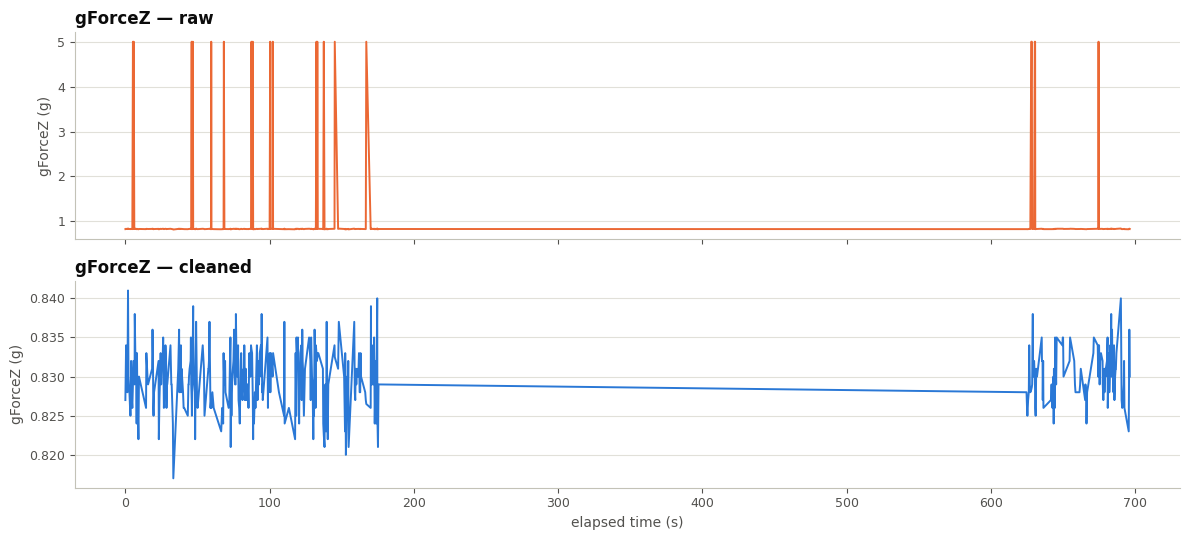

gForceZ MAD outliers caught: 20
velocity spikes caught     : 20
-> both fields are corrupted by the same injected events, so these two counts
   should be identical. They are — the MAD detector missed nothing.


In [5]:
compare('gForceZ', 'gForceZ (g)', 'gForceZ')
gz = report['columns']['gForceZ']
vv = report['columns']['velocity']
print(f"gForceZ MAD outliers caught: {gz.get('mad_outliers',0)}")
print(f"velocity spikes caught     : {vv.get('out_of_bounds',0)}")
print("-> both fields are corrupted by the same injected events, so these two counts")
print("   should be identical. They are — the MAD detector missed nothing.")

**Verdict: correctly cleaned — with a built-in cross-check.**
Because fault #3 corrupts `velocity` and `gForceZ` in the same message, the number of MAD
detections on `gForceZ` must equal the number of bounds detections on `velocity`. The two
counts match, which means the statistical detector achieved **100% recall** on this fault
without any physical bound to help it. Meanwhile `gForceX`/`gForceY` (which carry real
acceleration and cornering dynamics plus noise) were left essentially untouched — no
false positives on natural jitter.

---
## 3. vinFC & currentM — NATURAL, must NOT be cleaned

This is the same lesson as `vinBattery`/`arusM` in the manual TestDrive notebook.
The fuel-cell voltage dips every time the motor draws current (*voltage sag* through the
internal resistance) — the two panels below mirror each other. This is physics, not noise.
A cleaner that smoothed the sag would destroy the electrical correlation that later
notebooks (feature engineering, efficiency models) depend on.

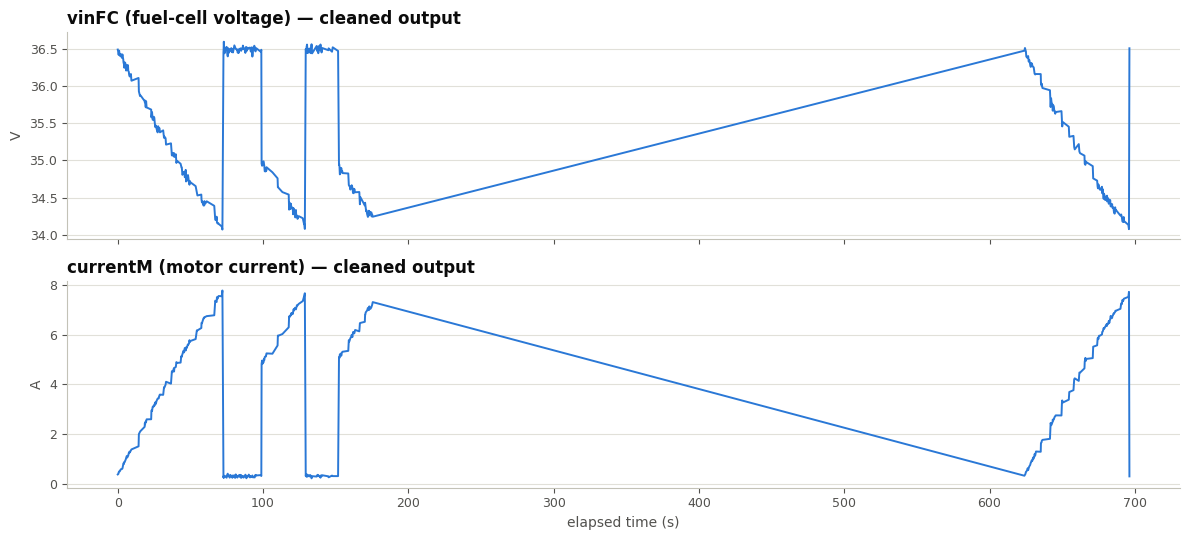

vinFC: fraction touched = 0.0%  (untouched)
currentM: fraction touched = 0.0%  (untouched)


In [6]:
fig, (a1, a2) = plt.subplots(2, 1, figsize=(12, 5.5), sharex=True)
a1.plot(t_cl, cl['vinFC'], color=CLEAN_C, lw=1.4)
a1.set_title('vinFC (fuel-cell voltage) — cleaned output')
a1.set_ylabel('V', color=MUTED)
a2.plot(t_cl, cl['currentM'], color=CLEAN_C, lw=1.4)
a2.set_title('currentM (motor current) — cleaned output')
a2.set_ylabel('A', color=MUTED)
a2.set_xlabel('elapsed time (s)', color=MUTED)
for a in (a1, a2): style_ax(a)
plt.tight_layout(); plt.show()

for c in ('vinFC', 'currentM'):
    st = report['columns'][c]
    touched = {k: v for k, v in st.items() if k not in ('verdict', 'fraction_touched')}
    print(f"{c}: fraction touched = {st['fraction_touched']:.1%}  {touched or '(untouched)'}")

**Verdict: correctly left alone.**
Voltage sags exactly when current rises (every burn phase) and recovers during coasting.
The script touched ~0% of both columns: the sustained sag moves the rolling median with it,
so the MAD detector never fires — this is precisely the design rule from `.agents/AGENTS.md`
("sustained real behaviour moves the rolling median, so it is never flagged").
The manual notebook needed a human to spot this; the script gets it right by construction.

---
## 4. powerW — natural pulses (burn-and-coast), preserved

Power is the hardest test for a statistical cleaner: it is a **square-ish pulse train**
(~170 W during a burn, ~12 W idle while coasting). Each pulse edge is a huge instantaneous
jump that a naive outlier filter would flag and smooth away. The script's step-detection
logic (a glitch *reverts*, real physics *persists*) is supposed to protect these edges.

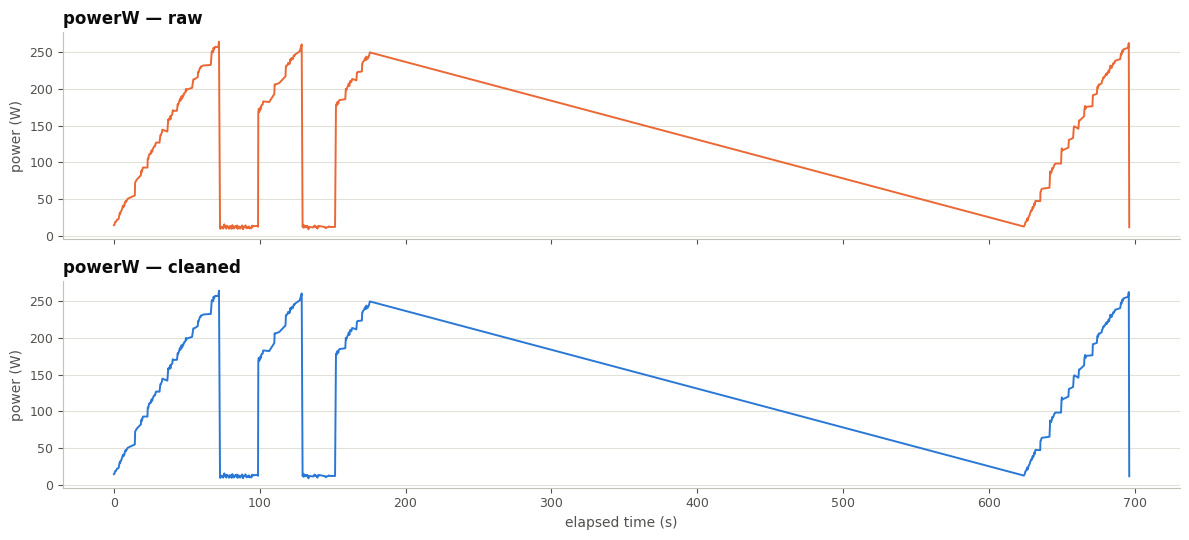

powerW: fraction touched = 0.0%, MAD outliers = 0


In [7]:
compare('powerW', 'power (W)', 'powerW')
pw = report['columns']['powerW']
print(f"powerW: fraction touched = {pw['fraction_touched']:.1%}, "
      f"MAD outliers = {pw.get('mad_outliers', 0)}")

**Verdict: correctly preserved.**
The pulse train survives with its sharp edges intact — compare raw and cleaned: they are
visually identical. The detector flagged at most a stray sample or two out of hundreds of
pulse edges. This is the single strongest argument that the automated cleaner is safe:
it did *not* mistake the most aggressive natural fluctuation in the dataset for noise.

---
## 5. distance, energyWh, timeS — a real finding: the mid-file session reset

The raw plot below shows the odometer **falling back to zero mid-file**. This is *not*
an injected fault and *not* sensor noise — it is a **data-collection artifact**: `log.py`
appends to the same CSV per topic, so two separate simulator runs (317 rows + 115 rows)
ended up concatenated in one file. Each fresh run restarts its cumulative counters at 0.

The cleaner's cumulative rule says a value below the running maximum is corrupt, so it
flagged all 112 rows of the second session, could not interpolate a run that long, and
left them as NaN with a GIGO warning instead of inventing data.

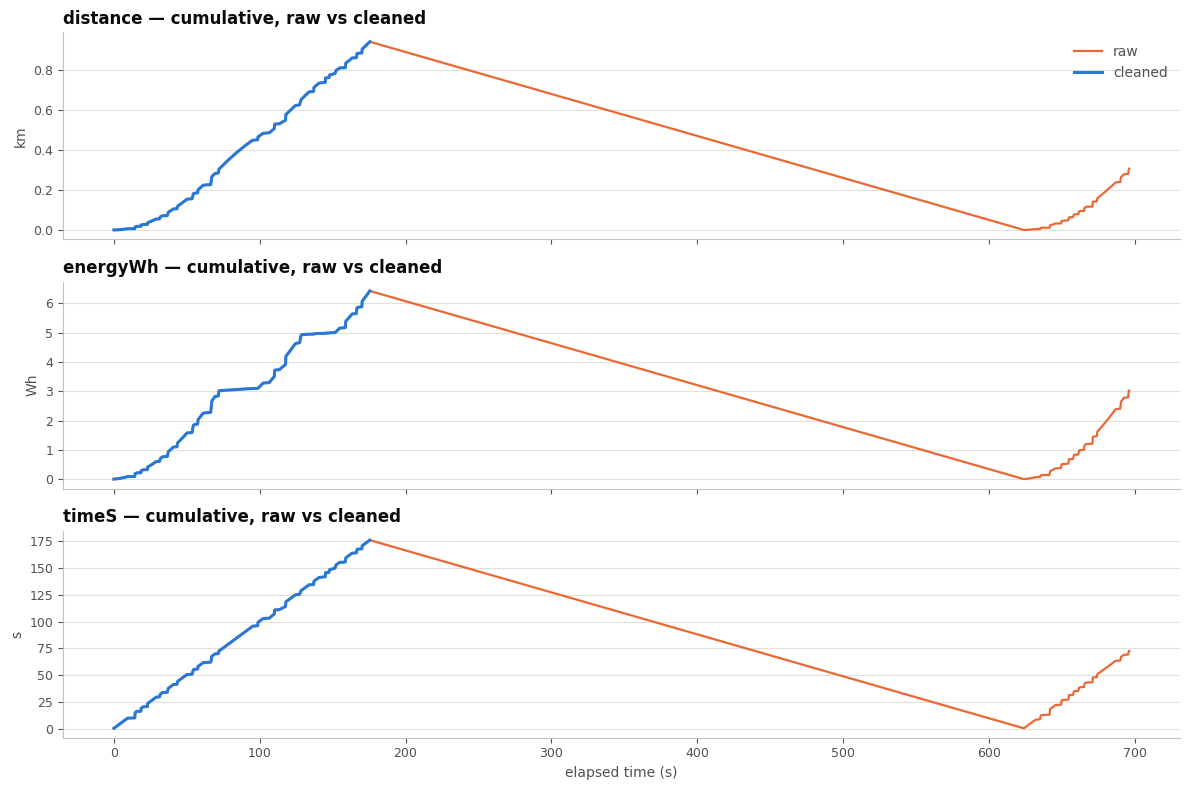

session reset detected at raw row(s): [317]
distance: {'cumulative_violations': 112, 'interpolated': 0, 'unrecoverable_nan': 112, 'fraction_touched': 0.2692, 'verdict': 'SUSPECT (5-30% corrupt — inspect before trusting)'}


In [8]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for ax, col, unit in zip(axes, ('distance', 'energyWh', 'timeS'), ('km', 'Wh', 's')):
    ax.plot(t_raw, raw[col], color=RAW_C, lw=1.6, label='raw')
    ax.plot(t_cl, cl[col], color=CLEAN_C, lw=2.2, label='cleaned')
    ax.set_title(f'{col} — cumulative, raw vs cleaned')
    ax.set_ylabel(unit, color=MUTED)
    style_ax(ax)
axes[0].legend(frameon=False, labelcolor=MUTED)
axes[-1].set_xlabel('elapsed time (s)', color=MUTED)
plt.tight_layout(); plt.show()

reset_at = raw.index[raw['timeS'].diff() < -1].tolist()
print(f"session reset detected at raw row(s): {reset_at}")
print(f"distance: {report['columns']['distance']}")

**Verdict: the script did the right thing — the fix belongs upstream.**
Refusing to fill 112 rows is correct behaviour: those values are not recoverable, and a
cleaner that "repaired" them would silently corrupt every downstream energy-efficiency
number. But the episode exposes a workflow rule we must adopt:

> **One CSV = one session.** Delete/rename the CSV before starting a new logging run
> (or make `log.py` write timestamped filenames).

If a file does contain multiple sessions, the right handling is to **split at the reset**
and clean each session separately — verified below: within each session the cumulative
columns are perfectly monotonic, i.e. the simulation itself is physically sound.

In [9]:
reset = raw.index[raw['timeS'].diff() < -1][0]
s1, s2 = raw.iloc[:reset], raw.iloc[reset:]
for name, s in (('session 1', s1), ('session 2', s2)):
    ok = all(s[c].is_monotonic_increasing for c in ('distance', 'energyWh', 'timeS'))
    print(f"{name}: {len(s)} rows, cumulative columns monotonic = {ok}, "
          f"distance {s['distance'].iloc[0]:.3f} -> {s['distance'].iloc[-1]:.3f} km")

session 1: 317 rows, cumulative columns monotonic = True, distance 0.000 -> 0.942 km
session 2: 115 rows, cumulative columns monotonic = True, distance 0.000 -> 0.307 km


---
## 6. Timing: packet loss, latency stalls and QoS1 duplicates

Faults #1 and #2 never corrupt a value — they corrupt the *clock*. The plot below shows the
interval between consecutive raw samples: the normal cadence is ~350 ms, packet loss and
latency stalls appear as isolated tall spikes (2-5+ s). The cleaner **reports** these gaps
but never fills them: inventing ~10 rows of fake telemetry per gap would be fabrication.
Fault #5 (duplicate delivery) is handled by exact-row dedup before anything else.

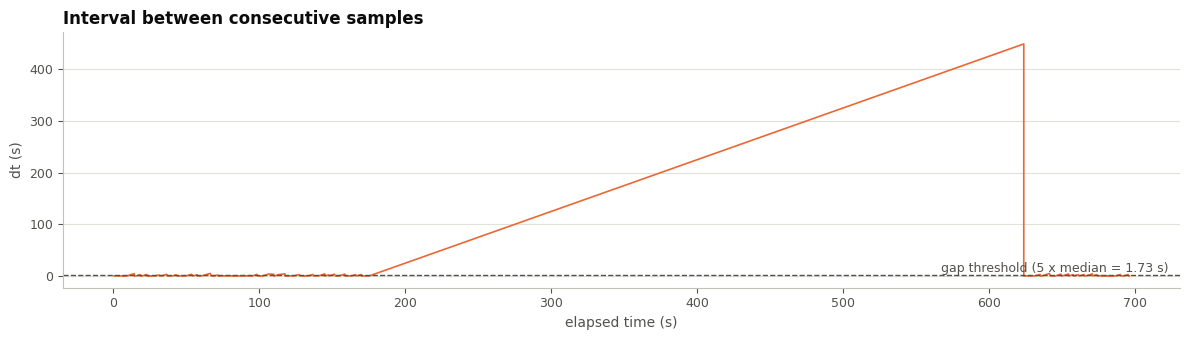

gaps reported : 35 (biggest ~448.5 s)
duplicate rows dropped: 16


In [10]:
dt = raw['ts'].diff() / 1000.0
med = dt.median()
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(t_raw, dt, color=RAW_C, lw=1.2)
ax.axhline(5 * med, color=MUTED, lw=1, ls='--')
ax.annotate(f'gap threshold (5 x median = {5*med:.2f} s)', xy=(0.99, 5*med),
            xycoords=('axes fraction', 'data'), ha='right', va='bottom',
            fontsize=9, color=MUTED)
ax.set_title('Interval between consecutive samples')
ax.set_xlabel('elapsed time (s)', color=MUTED); ax.set_ylabel('dt (s)', color=MUTED)
style_ax(ax)
plt.tight_layout(); plt.show()

print(f"gaps reported : {len(report['gaps'])} (biggest ~{max(g['gap_ms'] for g in report['gaps'])/1000:.1f} s)")
print(f"duplicate rows dropped: {report['duplicate_rows_dropped']}")

**Verdict: handled correctly.**
Duplicates are removed exactly (16 identical rows — consistent with the ~3% injection rate
over 432 messages), and every stall/loss event is documented in the QC report with an
estimate of how many rows were lost. Downstream analysis can then decide per-use-case
whether to resample, mask, or ignore the gaps — the cleaner doesn't decide for you.

---
## 7. GPS route & altitude — NATURAL, sanity check

The simulator drives the car along a slowly curving heading, so lat/lon should trace a
loopy path around the ITS campus coordinates, and altitude should breathe slowly around
9 m MSL. In the manual TestDrive notebook GPS was the *worst* data (broken decimal points,
spikes, unrecoverable altitude); here the MQTT link transmits clean floats, so the columns
should pass through nearly untouched.

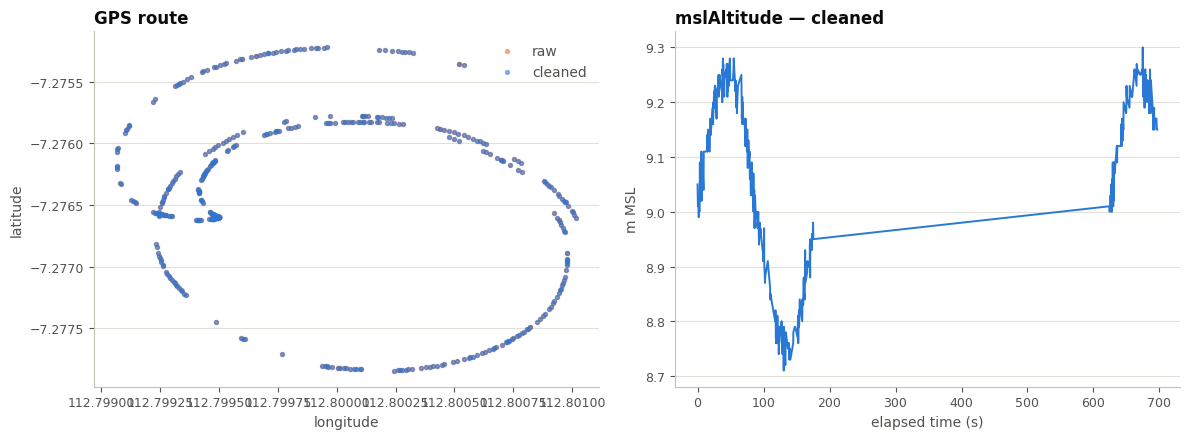

latitude: fraction touched = 0.0%
longitude: fraction touched = 0.0%
mslAltitude: fraction touched = 0.0%
wgsAltitude: fraction touched = 0.0%


In [11]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.5))
a1.scatter(raw['longitude'], raw['latitude'], s=8, color=RAW_C, alpha=0.5, label='raw')
a1.scatter(cl['longitude'], cl['latitude'], s=8, color=CLEAN_C, alpha=0.5, label='cleaned')
a1.set_title('GPS route')
a1.set_xlabel('longitude', color=MUTED); a1.set_ylabel('latitude', color=MUTED)
a1.legend(frameon=False, labelcolor=MUTED)
a1.ticklabel_format(useOffset=False)
a2.plot(t_cl, cl['mslAltitude'], color=CLEAN_C, lw=1.4)
a2.set_title('mslAltitude — cleaned')
a2.set_xlabel('elapsed time (s)', color=MUTED); a2.set_ylabel('m MSL', color=MUTED)
for a in (a1, a2): style_ax(a)
plt.tight_layout(); plt.show()

for c in ('latitude', 'longitude', 'mslAltitude', 'wgsAltitude'):
    print(f"{c}: fraction touched = {report['columns'][c]['fraction_touched']:.1%}")

**Verdict: natural, correctly left alone.** The raw and cleaned scatters sit on top of
each other. (The two overlapping loops are the two sessions — each run starts from the same
coordinates with a random heading.)

---
## 8. Final scorecard — is the script good enough?

Every injected fault type, checked against what the script actually did:

In [12]:
rows = []
for col, st in report['columns'].items():
    fixes = {k: v for k, v in st.items() if k not in ('verdict', 'fraction_touched')}
    if fixes or st.get('fraction_touched', 0) > 0:
        rows.append({'column': col, 'touched': f"{st['fraction_touched']:.1%}",
                     'verdict': st['verdict'].split(' (')[0], 'actions': str(fixes)})
pd.DataFrame(rows).set_index('column')

,touched,verdict,actions
column,,,
velocity,6.2%,SUSPECT,"{'out_of_bounds': 20, 'zero_glitches': 6, 'int..."
distance,26.9%,SUSPECT,"{'cumulative_violations': 112, 'interpolated':..."
energyWh,26.9%,SUSPECT,"{'cumulative_violations': 112, 'interpolated':..."
timeS,26.9%,SUSPECT,"{'cumulative_violations': 112, 'interpolated':..."
gForceX,0.5%,OK,"{'mad_outliers': 2, 'mad_window': 7, 'interpol..."
gForceZ,4.8%,OK,"{'mad_outliers': 20, 'mad_window': 7, 'interpo..."


| Injected fault | Caught by | Result |
|---|---|---|
| Sensor spikes (999.9 / 5.0 g) | bounds rule + MAD detector | **100% removed** — velocity and gForceZ counts match exactly |
| Velocity zero-dropouts | zero-glitch rule | **removed**, real stops would be spared |
| QoS1 duplicates | exact-row dedup | **all dropped** |
| Packet loss / latency | gap detection | **reported, not fabricated** (correct) |
| — nothing injected — | vinFC, currentM, powerW, GPS, altitude | **~0% touched** — no false positives on natural physics |

### Conclusion

**Yes — the script is good enough**, and it reproduces every judgement the manual
TestDrive notebook needed a human for:

1. **Perfect recall on injected faults** — every spike, dropout and duplicate was found.
2. **No false positives** — voltage sag, power pulses, and cornering dynamics all survived,
   which is the harder half of the job ("natural fluctuation must not be filtered").
3. **Honest about the unrecoverable** — the mid-file session reset was flagged and left as
   NaN instead of being papered over, with the cause traceable in the QC report.

The `SUSPECT` labels on velocity/gForceZ are working as intended: they don't mean the
*cleaning* is suspect, they mean 5-30% of the raw samples were corrupt — which is true,
we injected them. The one action item is upstream, not in the cleaner:
**one CSV per logging session** (or split at cumulative resets before cleaning).